In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / 'data' / 'processed_data'

nav         = pd.read_csv(PROCESSED_DIR / 'clean_nav.csv', parse_dates=['date'])
fund_master = pd.read_csv(PROCESSED_DIR / 'clean_fund_master.csv')
benchmark   = pd.read_csv(PROCESSED_DIR / 'clean_benchmark_indices.csv', parse_dates=['date'])
perf        = pd.read_csv(PROCESSED_DIR / 'clean_performance.csv')

nav = nav.sort_values(['amfi_code', 'date'])
print("✅ Data loaded")
print(f"Funds: {nav['amfi_code'].nunique()}")
print(f"Date range: {nav['date'].min()} → {nav['date'].max()}")

✅ Data loaded
Funds: 40
Date range: 2022-01-03 00:00:00 → 2026-05-29 00:00:00


In [2]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
nav = nav.dropna(subset=['daily_return'])

print("✅ Daily returns computed")
print(nav[['amfi_code','date','nav','daily_return']].head())

✅ Daily returns computed
   amfi_code       date       nav  daily_return
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639


In [3]:
def compute_cagr(nav_df, amfi_code, years):
    df = nav_df[nav_df['amfi_code'] == amfi_code].sort_values('date')
    end_date = df['date'].max()
    start_date = end_date - pd.DateOffset(years=years)
    df_period = df[df['date'] >= start_date]
    if len(df_period) < 2:
        return None
    nav_start = df_period['nav'].iloc[0]
    nav_end   = df_period['nav'].iloc[-1]
    n_days    = len(df_period)
    cagr = (nav_end / nav_start) ** (252 / n_days) - 1
    return round(cagr * 100, 2)

# Compute for all funds
cagr_results = []
for code in nav['amfi_code'].unique():
    name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else str(code)
    cagr_results.append({
        'amfi_code':  code,
        'scheme_name': name,
        'cagr_1yr':   compute_cagr(nav, code, 1),
        'cagr_3yr':   compute_cagr(nav, code, 3),
        'cagr_5yr':   compute_cagr(nav, code, 5),
    })

cagr_df = pd.DataFrame(cagr_results)
cagr_df.to_csv(PROCESSED_DIR / 'cagr_report.csv', index=False)
print("✅ CAGR computed for all funds")
print(cagr_df.sort_values('cagr_3yr', ascending=False).head(10).to_string(index=False))

✅ CAGR computed for all funds
 amfi_code                                        scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
    119094                Axis Midcap Fund - Regular - Growth     21.33     33.62     27.20
    148567      Mirae Asset Large Cap Fund - Regular - Growth     19.51     32.56     29.20
    120504          ICICI Pru Bluechip Fund - Direct - Growth     12.54     31.12     22.70
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth     50.76     31.07     29.31
    120505           ICICI Pru Midcap Fund - Regular - Growth     28.33     30.44     32.09
    119551          SBI Bluechip Fund - Regular Plan - Growth     57.57     29.18     24.82
    120843             Kotak Flexicap Fund - Regular - Growth     25.52     28.35     29.17
    148569      Mirae Asset Tax Saver Fund - Regular - Growth     37.98     27.96     30.43
    101206      ABSL Frontline Equity Fund - Regular - Growth     45.73     27.76     22.60
    149324              DSP Small Cap Fund - Regul

In [4]:
RF_DAILY = 0.065 / 252  # 6.5% annual risk free rate

sharpe_results = []
for code in nav['amfi_code'].unique():
    df = nav[nav['amfi_code'] == code]['daily_return'].dropna()
    if len(df) < 30:
        continue
    excess = df.mean() - RF_DAILY
    sharpe = (excess / df.std()) * np.sqrt(252)
    sharpe_results.append({
        'amfi_code': code,
        'sharpe_ratio_computed': round(sharpe, 4)
    })

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df.to_csv(PROCESSED_DIR / 'sharpe_values.csv', index=False)
print("✅ Sharpe Ratio computed")
print(sharpe_df.sort_values('sharpe_ratio_computed', ascending=False).head(10).to_string(index=False))

✅ Sharpe Ratio computed
 amfi_code  sharpe_ratio_computed
    148567                 1.4483
    120843                 1.3067
    148569                 1.2349
    119551                 1.2083
    120505                 1.1801
    149323                 1.1321
    100033                 1.0937
    118632                 1.0817
    101206                 1.0272
    120504                 1.0265


In [5]:
sortino_results = []
for code in nav['amfi_code'].unique():
    df = nav[nav['amfi_code'] == code]['daily_return'].dropna()
    if len(df) < 30:
        continue
    excess = df.mean() - RF_DAILY
    downside = df[df < 0].std()
    sortino = (excess / downside) * np.sqrt(252) if downside > 0 else None
    sortino_results.append({
        'amfi_code': code,
        'sortino_ratio': round(sortino, 4) if sortino else None
    })

sortino_df = pd.DataFrame(sortino_results)
sortino_df.to_csv(PROCESSED_DIR / 'sortino_values.csv', index=False)
print("✅ Sortino Ratio computed")
print(sortino_df.sort_values('sortino_ratio', ascending=False).head(10).to_string(index=False))

✅ Sortino Ratio computed
 amfi_code  sortino_ratio
    148567         2.3856
    120843         2.3643
    148569         2.1469
    119551         2.1403
    120505         2.0294
    149323         1.8751
    118632         1.8501
    100033         1.8291
    120504         1.8053
    101206         1.7996


In [6]:
nifty100 = benchmark[benchmark['index_name'] == 'NIFTY100'].sort_values('date')
nifty100['bench_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna()

alpha_beta_results = []
for code in nav['amfi_code'].unique():
    fund_ret = nav[nav['amfi_code'] == code][['date','daily_return']].dropna()
    merged = fund_ret.merge(nifty100[['date','bench_return']], on='date')
    if len(merged) < 30:
        continue
    slope, intercept, r, p, se = stats.linregress(
        merged['bench_return'], merged['daily_return']
    )
    alpha_beta_results.append({
        'amfi_code': code,
        'beta':  round(slope, 4),
        'alpha': round(intercept * 252 * 100, 4),
        'r_squared': round(r**2, 4)
    })

ab_df = pd.DataFrame(alpha_beta_results)
ab_df.to_csv(PROCESSED_DIR / 'alpha_beta.csv', index=False)
print("✅ Alpha & Beta computed")
print(ab_df.head(10).to_string(index=False))

✅ Alpha & Beta computed
 amfi_code    beta   alpha  r_squared
    100016 -0.0583  3.7476     0.0027
    100025  0.0012  4.2818     0.0000
    100033  0.0051 27.1954     0.0000
    101206  0.0211 21.3998     0.0003
    101207 -0.0653 10.8971     0.0011
    101208  0.0003  6.0861     0.0000
    102885 -0.0195 17.0488     0.0004
    102886 -0.0421  2.8969     0.0009
    102887  0.0167 16.2113     0.0002
    118632 -0.0084 21.8294     0.0001


In [7]:
drawdown_results = []
for code in nav['amfi_code'].unique():
    df = nav[nav['amfi_code'] == code].sort_values('date')
    rolling_max = df['nav'].cummax()
    drawdown = (df['nav'] - rolling_max) / rolling_max
    max_dd = drawdown.min()
    drawdown_results.append({
        'amfi_code': code,
        'max_drawdown_pct': round(max_dd * 100, 4)
    })

dd_df = pd.DataFrame(drawdown_results)
dd_df.to_csv(PROCESSED_DIR / 'max_drawdown.csv', index=False)
print("✅ Max Drawdown computed")
print(dd_df.sort_values('max_drawdown_pct').head(10).to_string(index=False))

✅ Max Drawdown computed
 amfi_code  max_drawdown_pct
    119599          -52.5742
    119095          -51.6778
    101207          -35.4469
    149324          -31.1719
    119598          -28.7060
    102886          -28.0011
    100016          -24.7344
    120842          -24.0035
    118634          -23.3449
    119093          -21.7514


In [8]:
# Merge all metrics
scorecard = cagr_df[['amfi_code','scheme_name','cagr_3yr']].copy()
scorecard = scorecard.merge(sharpe_df, on='amfi_code')
scorecard = scorecard.merge(ab_df[['amfi_code','alpha']], on='amfi_code')
scorecard = scorecard.merge(dd_df, on='amfi_code')
scorecard = scorecard.merge(
    fund_master[['amfi_code','expense_ratio_pct']], on='amfi_code'
)

# Rank each metric
scorecard['rank_return']   = scorecard['cagr_3yr'].rank(ascending=True)
scorecard['rank_sharpe']   = scorecard['sharpe_ratio_computed'].rank(ascending=True)
scorecard['rank_alpha']    = scorecard['alpha'].rank(ascending=True)
scorecard['rank_expense']  = scorecard['expense_ratio_pct'].rank(ascending=False)
scorecard['rank_drawdown'] = scorecard['max_drawdown_pct'].rank(ascending=False)

# Composite score (weights from PDF)
scorecard['score'] = (
    0.30 * scorecard['rank_return'] +
    0.25 * scorecard['rank_sharpe'] +
    0.20 * scorecard['rank_alpha']  +
    0.15 * scorecard['rank_expense']+
    0.10 * scorecard['rank_drawdown']
)

# Normalise to 0-100
scorecard['score_100'] = (
    (scorecard['score'] - scorecard['score'].min()) /
    (scorecard['score'].max() - scorecard['score'].min()) * 100
).round(2)

scorecard = scorecard.sort_values('score_100', ascending=False)
scorecard.to_csv(PROCESSED_DIR / 'fund_scorecard.csv', index=False)
print("✅ Fund Scorecard computed")
print(scorecard[['scheme_name','cagr_3yr','sharpe_ratio_computed',
                  'alpha','max_drawdown_pct','score_100']].head(10).to_string(index=False))

✅ Fund Scorecard computed
                                       scheme_name  cagr_3yr  sharpe_ratio_computed   alpha  max_drawdown_pct  score_100
          ICICI Pru Midcap Fund - Regular - Growth     30.44                 1.1801 29.2636          -18.1885     100.00
               Axis Midcap Fund - Regular - Growth     33.62                 0.9982 26.0767          -20.9609      94.18
HDFC Mid-Cap Opportunities Fund - Regular - Growth     31.07                 1.0937 27.1954          -16.2172      93.79
     Mirae Asset Large Cap Fund - Regular - Growth     32.56                 1.4483 26.9838          -11.2657      93.02
            Kotak Flexicap Fund - Regular - Growth     28.35                 1.3067 27.3305          -12.9740      90.30
         ICICI Pru Bluechip Fund - Direct - Growth     31.12                 1.0265 21.1948          -12.5883      86.42
        SBI Small Cap Fund - Regular Plan - Growth     25.57                 0.9453 30.3370          -28.7060      85.45
      

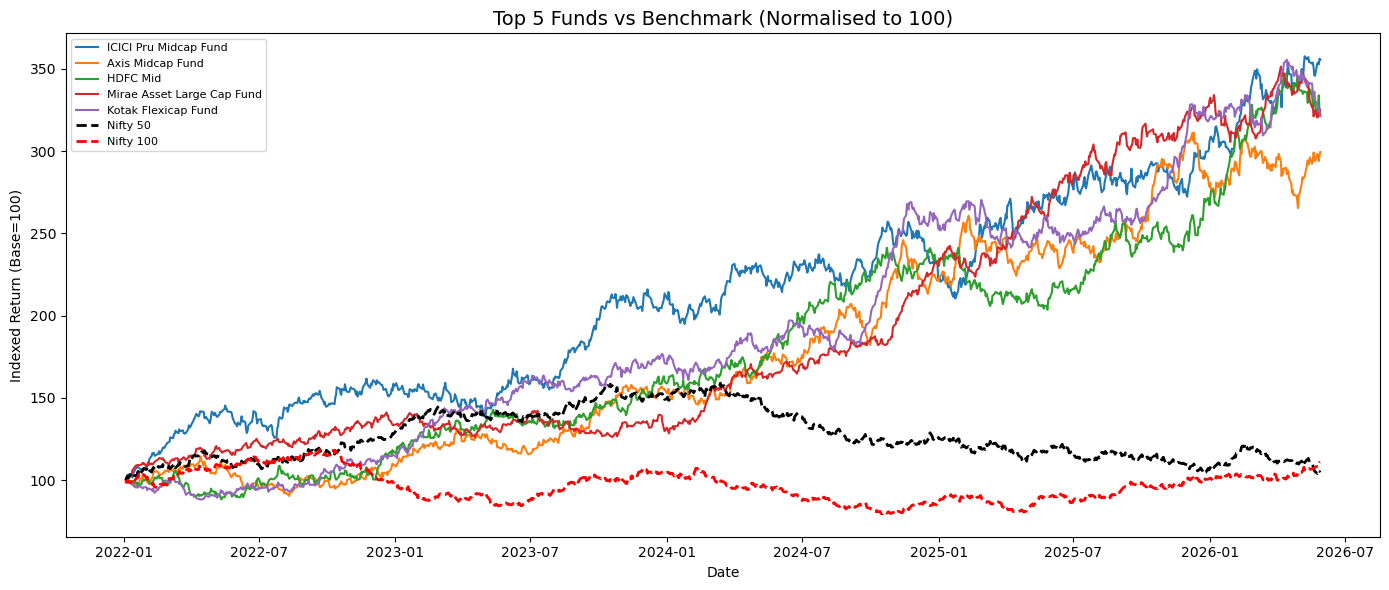

✅ Benchmark chart saved


In [9]:
top5_codes = scorecard.head(5)['amfi_code'].tolist()
nifty50 = benchmark[benchmark['index_name'] == 'NIFTY50'].sort_values('date')
nifty100_b = benchmark[benchmark['index_name'] == 'NIFTY100'].sort_values('date')

plt.figure(figsize=(14,6))

for code in top5_codes:
    df = nav[nav['amfi_code'] == code].sort_values('date')
    name = fund_master[fund_master['amfi_code']==code]['scheme_name'].values[0]
    short = name.split('-')[0].strip()
    # Normalise to 100
    df = df.copy()
    df['norm'] = df['nav'] / df['nav'].iloc[0] * 100
    plt.plot(df['date'], df['norm'], label=short, linewidth=1.5)

# Benchmarks normalised
n50 = nifty50.copy()
n50['norm'] = n50['close_value'] / n50['close_value'].iloc[0] * 100
plt.plot(n50['date'], n50['norm'], 'k--', label='Nifty 50', linewidth=2)

n100 = nifty100_b.copy()
n100['norm'] = n100['close_value'] / n100['close_value'].iloc[0] * 100
plt.plot(n100['date'], n100['norm'], 'r--', label='Nifty 100', linewidth=2)

plt.title('Top 5 Funds vs Benchmark (Normalised to 100)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Indexed Return (Base=100)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'benchmark_chart.png', dpi=150)
plt.show()
print("✅ Benchmark chart saved")